## VAE

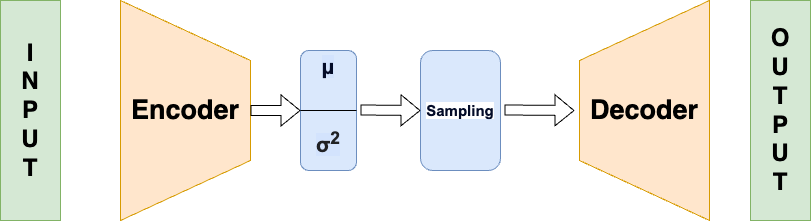

## CVAE

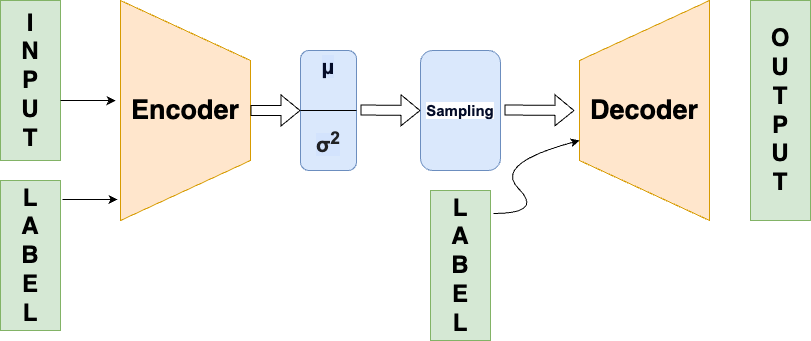

## KL Divergence

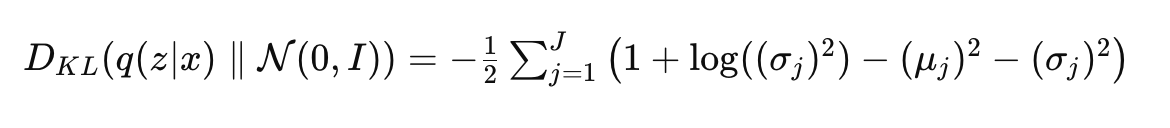

# Imports

In [ ]:
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Conv2D, Flatten, Lambda, concatenate
from tensorflow.keras.layers import Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
from tensorflow.keras.losses import mse, binary_crossentropy
from tensorflow.keras.utils import plot_model, to_categorical
from tensorflow.keras import backend as K

import numpy as np
import matplotlib.pyplot as plt
import argparse
import os

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

image_size = x_train.shape[1]
x_train = np.reshape(x_train, [-1, image_size, image_size, 1])
x_test = np.reshape(x_test, [-1, image_size, image_size, 1])
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

11490434/11490434 [==============================] - 1s 0us/step


In [ ]:
num_labels = len(np.unique(y_train))

In [ ]:
num_labels

10

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
image_size

28

In [ ]:
def sampling(args):
    z_mean, z_log_variance = args

    batch_size = K.shape(z_mean)[0]
    dim = K.int_shape(z_mean)[1]

    epsilon = K.random_normal(shape=(batch_size,dim))

    return z_mean + K.exp(0.5 * z_log_variance)*epsilon


In [ ]:
input_shape = (image_size,image_size,1)
label_shape = (num_labels,)
batch_size=128
kernel_size=3
layer_fiters = [16,32]
latent_dim = 2
epochs= 30

# Encoder

In [ ]:
28*28

784

In [ ]:
inputs = Input(shape=(input_shape),name="encoder_input") #(28x28x1)
y_label = Input(shape=label_shape,name='label_info') # (10,)
x = Dense(image_size*image_size)(y_label) #(784,)
x = Reshape((image_size,image_size,1))(x) #(28x28x1)

x = concatenate([inputs,x]) #(28x28x2)

for filter_size in layer_fiters:
    x = Conv2D(filters=filter_size,
               kernel_size=kernel_size,
               activation='relu',
               strides=2,
               padding='same')(x)

conv_latent_shape = K.int_shape(x)

x = Flatten()(x)
x = Dense(16,activation='relu')(x)

z_mean = Dense(latent_dim,name="z_mean")(x)
z_log_var = Dense(latent_dim,name="z_variance")(x)

z = Lambda(sampling,output_shape=latent_dim,name='z')([z_mean,z_log_var])

In [ ]:
encoder_model = Model([inputs,y_label],[z_mean,z_log_var,z],name="encoder_model")

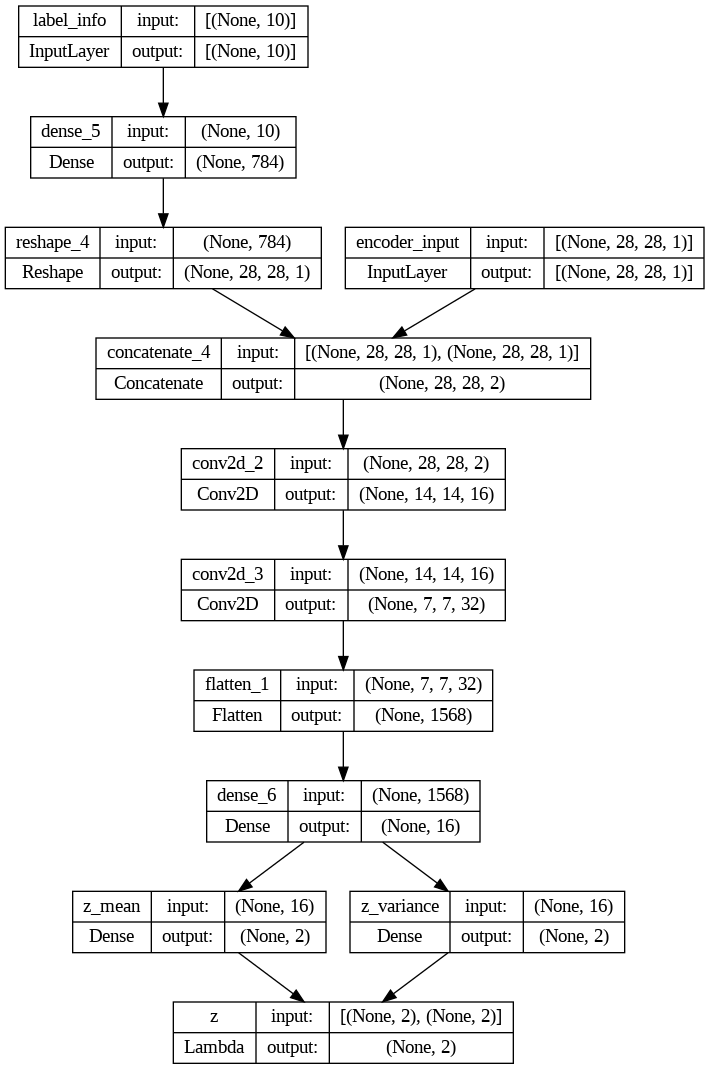

In [ ]:
plot_model(encoder_model,show_shapes=True)

# decoder

In [ ]:
layer_fiters

[16, 32]

In [ ]:
latent_inputs = Input(shape=(latent_dim),name='decoder_input') #(2,)
x = concatenate([latent_inputs,y_label]) #(12,)

x = Dense(conv_latent_shape[1]*conv_latent_shape[2]*conv_latent_shape[3])(x)
x = Reshape((conv_latent_shape[1],conv_latent_shape[2],conv_latent_shape[3]))(x)

for filter_size in layer_fiters[::-1]:
    x = Conv2DTranspose(filters=filter_size,
                        kernel_size=kernel_size,
                        activation='relu',
                        strides=2,
                        padding='same')(x)

output = Conv2DTranspose(filters=1,
                         kernel_size=kernel_size,
                         activation='sigmoid',
                         padding='same',
                         name= "decoder_output"
                         )(x)

In [ ]:
decoder_model = Model([latent_inputs,y_label],output,name="decoder_model")

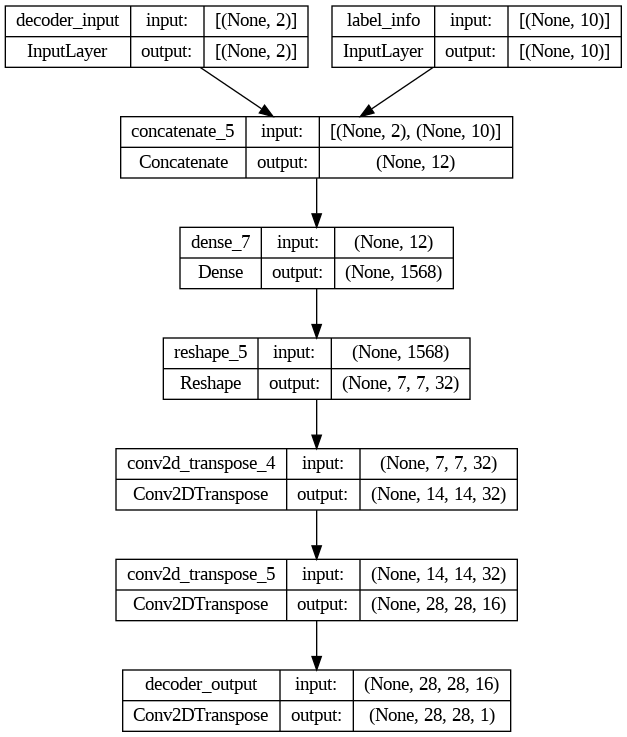

In [ ]:
plot_model(decoder_model,show_shapes=True)

# VAE

In [ ]:
intermediate_output = decoder_model([encoder_model([inputs,y_label])[2],y_label])
cvae = Model([inputs,y_label],intermediate_output,name='cvae')

## losses

In [ ]:
reconstruction_loss = mse(K.flatten(inputs),K.flatten(intermediate_output))
reconstruction_loss *= image_size*image_size

kl_loss = 1 + z_log_var - K.square(z_mean) - K.exp(z_log_var)
kl_loss = K.sum(kl_loss,axis=-1)
kl_loss = kl_loss* -0.5

vae_loss = K.mean(reconstruction_loss + kl_loss)


cvae.add_loss(vae_loss)
cvae.compile(optimizer='adam')


In [ ]:
cvae.fit([x_train,to_categorical(y_train)],
        epochs=epochs,
        batch_size=batch_size,
        validation_data=([x_test,to_categorical(y_test)],None))

Epoch 1/30
469/469 [==============================] - 13s 11ms/step - loss: 51.3252 - val_loss: 38.6892
Epoch 2/30
469/469 [==============================] - 4s 9ms/step - loss: 34.3903 - val_loss: 32.4493
Epoch 3/30
469/469 [==============================] - 5s 10ms/step - loss: 32.0561 - val_loss: 31.6725
Epoch 4/30
469/469 [==============================] - 4s 8ms/step - loss: 31.5235 - val_loss: 31.3393
Epoch 5/30
469/469 [==============================] - 4s 8ms/step - loss: 31.2136 - val_loss: 31.0816
Epoch 6/30
469/469 [==============================] - 5s 10ms/step - loss: 31.0111 - val_loss: 30.8974
Epoch 7/30
469/469 [==============================] - 4s 9ms/step - loss: 30.8468 - val_loss: 30.8184
Epoch 8/30
469/469 [==============================] - 5s 11ms/step - loss: 30.7059 - val_loss: 30.6932
Epoch 9/30
469/469 [==============================] - 6s 12ms/step - loss: 30.5851 - val_loss: 30.5677
Epoch 10/30
469/469 [==============================] - 6s 14ms/step - loss: 

In [ ]:
def plot_imgs(imgs):
    _,axs = plt.subplots(5,5,figsize=(10,10))

    axs = axs.flatten()

    for img,ax in zip(imgs,axs):
        ax.imshow(img,cmap='gray')

    plt.show()


In [ ]:
res = cvae.predict((x_test[:25],to_categorical(y_test[:25])))

1/1 [==============================] - 0s 417ms/step


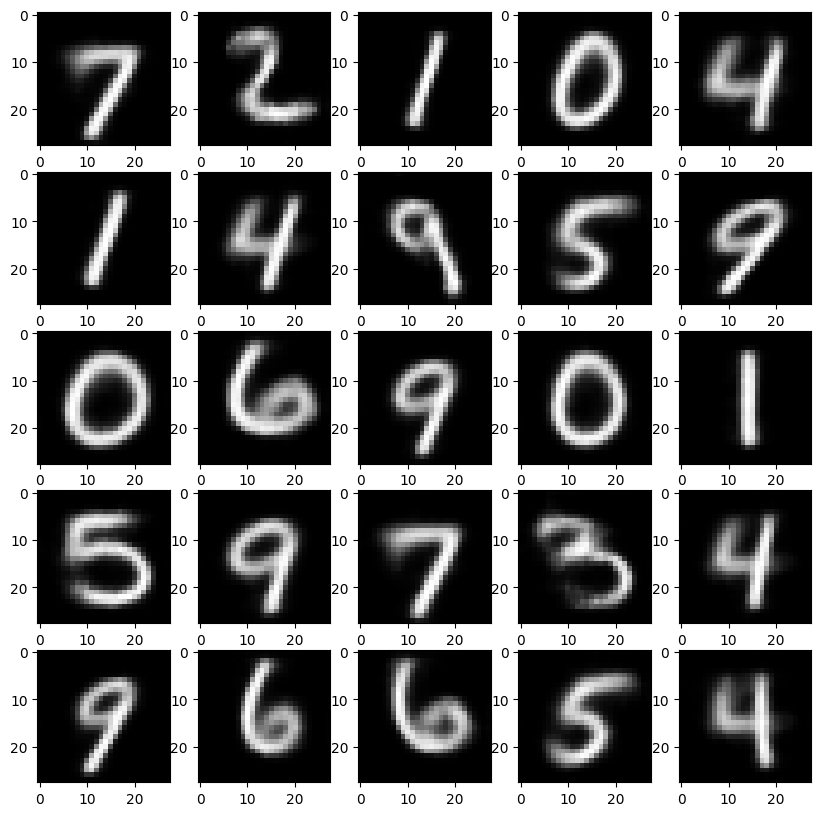

In [ ]:
plot_imgs(res)

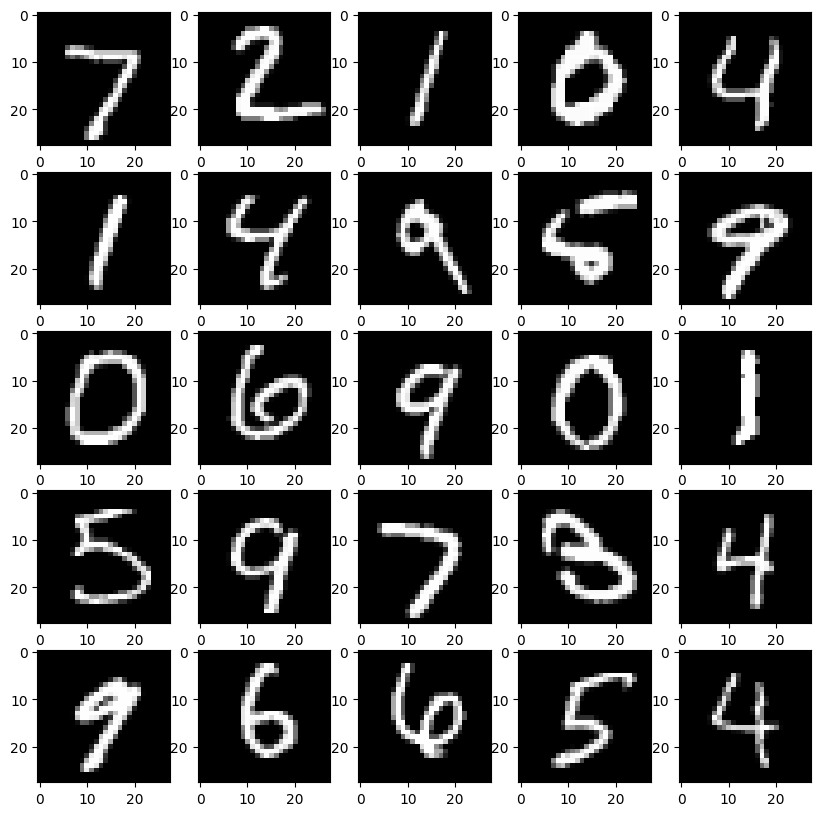

In [ ]:
plot_imgs(x_test[:25])
